# Reproducing Diebold-Yilmaz (2009)

**Diebold, F. X. & Yilmaz, K. (2009).** *Measuring Financial Asset Return and Volatility Spillovers, with Application to Global Equity Markets.*
**The Economic Journal, 119(534), 158–171.**

This notebook reconstructs the full-sample **return** and **volatility** spillover tables of the 2009 paper with `pyconnectedness`, and reproduces the two headline numbers: a **return** spillover index of **35.5 %** (Table 3) and a **volatility** spillover index of about **39.5 %**.

The 2009 paper uses an **orthogonalized (Cholesky)** variance decomposition, which depends on the ordering of the variables — a point we check explicitly below, and which motivates the *generalized* decomposition of Diebold–Yilmaz (2012).



In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from pyconnectedness import static_connectedness, dynamic_connectedness

# paths below are relative to the repository root
while not os.path.isdir("examples") and os.path.basename(os.getcwd()):
    os.chdir("..")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## Data

Weekly data for **19 global equity markets**, early 1990s to 2007. Two aligned panels: log returns and a weekly volatility measure. One column per market, a `DatetimeIndex` on the rows - the wide, pandas-native layout that `static_connectedness` expects.

In [8]:
returns = pd.read_excel("examples/data/dy2009_returns.xlsx").set_index("date")
volatility = pd.read_excel("examples/data/dy2009_vola.xlsx").set_index("date")

print("Markets:", list(returns.columns))
print("Observations:", len(returns), "| Missing:", int(returns.isna().sum().sum()))
print("Sample:", returns.index.min().date(), "->", returns.index.max().date())

Markets: ['djia', 'ftse', 'fra', 'ger', 'hkg', 'jpn', 'aus', 'idn', 'kor', 'mys', 'phl', 'sgp', 'tai', 'tha', 'arg', 'bra', 'chl', 'mex', 'tur']
Observations: 829 | Missing: 0
Sample: 1992-01-10 -> 2007-11-23


## Table 1 - Descriptive Statistics

Diebold–Yilmaz (2009), Table 1. Two conventions matter for an exact match: kurtosis is reported **raw** (a normal distribution gives 3, not 0), and both skewness and kurtosis use the **population (biased)** estimator. In `scipy` that is `fisher=False` and `bias=True`.

In [3]:
table1 = pd.DataFrame({
    "Mean":     returns.mean(),
    "Median":   returns.median(),
    "Maximum":  returns.max(),
    "Minimum":  returns.min(),
    "Std.Dev.": returns.std(ddof=1),
    "Skewness": pd.Series(stats.skew(returns, bias=True), index=returns.columns),
    "Kurtosis": pd.Series(stats.kurtosis(returns, fisher=False, bias=True), index=returns.columns),
}).T
table1.round(5)

,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur
Mean,0.00108,0.00037,0.00095,0.00144,0.00134,-0.00051,0.00096,0.00057,0.00047,0.00052,0.00001,0.00090,0.00032,-0.00055,-0.00002,0.00225,0.00112,0.00134,-0.00183
Median,0.00249,0.00127,0.00109,0.00356,0.00256,0.00080,0.00207,0.00163,0.00163,0.00084,0.00036,0.00146,0.00236,0.00080,0.00338,0.00448,0.00102,0.00365,-0.00035
Maximum,0.08015,0.09915,0.10981,0.12942,0.13616,0.11076,0.07044,0.18192,0.17486,0.24264,0.15987,0.18363,0.18671,0.21783,0.24283,0.21935,0.09088,0.17031,0.31551
Minimum,-0.15444,-0.08823,-0.12169,-0.14036,-0.20149,-0.11425,-0.05281,-0.20090,-0.21828,-0.19102,-0.22084,-0.24265,-0.14154,-0.17293,-0.20193,-0.25158,-0.07129,-0.17829,-0.38140
Std.Dev.,0.02085,0.02068,0.02705,0.02948,0.03481,0.02878,0.01611,0.03827,0.04210,0.03220,0.03536,0.03069,0.03566,0.03905,0.05120,0.05548,0.02093,0.03599,0.06477
Skewness,-0.72717,-0.10836,-0.13344,-0.27715,-0.44040,-0.01930,-0.18554,-0.29091,-0.33285,0.13408,-0.31194,-0.61057,0.01157,0.14976,0.02265,-0.29569,0.07717,-0.30595,-0.27740
Kurtosis,7.60941,4.79030,4.15329,5.18385,5.88410,3.96384,3.86330,7.59406,6.20905,11.13712,7.12762,12.99616,5.21114,5.42928,5.46708,5.07689,4.50715,5.35168,7.14676


## Table 2 - Descriptive Statistics - Vola


Same statistics for the volatility panel (Diebold–Yilmaz 2009, Table 2). Volatilities are strongly right-skewed and heavy-tailed, in contrast to the near-symmetric returns above.

In [4]:
table2 = pd.DataFrame({
    "Mean":     volatility.mean(),
    "Median":   volatility.median(),
    "Maximum":  volatility.max(),
    "Minimum":  volatility.min(),
    "Std.Dev.": volatility.std(ddof=1),
    "Skewness": pd.Series(stats.skew(volatility, bias=True), index=volatility.columns),
    "Kurtosis": pd.Series(stats.kurtosis(volatility, fisher=False, bias=True), index=volatility.columns),
}).T
table2.round(5)

,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur
Mean,0.00042,0.00049,0.00075,0.00083,0.00099,0.00072,0.00023,0.00087,0.00128,0.00085,0.00065,0.00045,0.00079,0.00111,0.00187,0.00210,0.00021,0.00102,0.00317
Median,0.00025,0.00024,0.00043,0.00035,0.00050,0.00050,0.00015,0.00036,0.00064,0.00024,0.00033,0.00020,0.00049,0.00056,0.00085,0.00108,0.00010,0.00053,0.00152
Maximum,0.00595,0.00926,0.01013,0.01629,0.03794,0.00798,0.01045,0.02074,0.01869,0.04592,0.01797,0.01050,0.01376,0.02356,0.03371,0.06133,0.00816,0.02870,0.07689
Minimum,0.00002,0.00001,0.00003,0.00001,0.00002,0.00002,0.00001,0.00000,0.00000,0.00000,0.00000,0.00000,0.00001,0.00003,0.00001,0.00000,0.00000,0.00000,0.00000
Std.Dev.,0.00056,0.00079,0.00104,0.00148,0.00204,0.00079,0.00044,0.00169,0.00192,0.00287,0.00137,0.00081,0.00099,0.00179,0.00327,0.00419,0.00048,0.00180,0.00539
Skewness,4.41977,5.45612,4.25545,4.80717,10.28536,3.56561,16.36687,5.05674,3.88355,10.51185,8.31022,5.33902,4.76813,5.73145,4.99326,7.72435,8.82490,7.87276,6.79783
Kurtosis,30.74238,44.80058,27.33654,34.11062,156.41991,22.41701,361.96651,39.06700,23.23604,137.33461,92.21124,45.60179,45.59744,52.31016,35.89735,82.96087,113.73667,96.06101,73.76338


## The spillover index


Fit a covariance-stationary $\mathrm{VAR}(p)$,

$$x_t = \sum_{i=1}^{p} \Phi_i\, x_{t-i} + \varepsilon_t,
\qquad \varepsilon_t \sim (0,\Sigma),$$

with moving-average representation $x_t = \sum_{h=0}^{\infty} A_h\,\varepsilon_{t-h}$. The 2009 paper identifies **orthogonal** shocks through the Cholesky factor $P$ of $\Sigma$ ($\Sigma = P P'$). The share of the $H$-step forecast-error variance of variable $i$ due to shocks in variable $j$ is

$$\theta_{ij}(H)=
\frac{\sum_{h=0}^{H-1}\big(e_i' A_h P\, e_j\big)^2}
{\sum_{h=0}^{H-1} e_i' A_h \Sigma A_h' e_i}.$$

Because the shocks are orthogonal, each row sums to one, $\sum_j \theta_{ij}(H)=1$. The **total spillover index** is the off-diagonal share of the decomposition,

$$S(H)=\frac{\sum_{i\neq j}\theta_{ij}(H)}{\sum_{i,j}\theta_{ij}(H)}\times 100
=\frac{\sum_{i\neq j}\theta_{ij}(H)}{K}\times 100 .$$

The paper uses a $\mathrm{VAR}(2)$ and a $10$-week-ahead horizon, so `method="orthogonalized"`, `lags=2`, `horizon=10`.

## Table 3 - Return Spillover 

The full spillover table in Diebold–Yilmaz layout: the normalized decomposition (in %), the `FROM` column (shocks received from others), the `TO` row (shocks transmitted to others), and the `NET` row. The bottom-right corner of the `TO_incl_own` row is the **total return spillover index — the paper reports 35.5 %.**

In [5]:
ret_conn = static_connectedness(returns, horizon=10, method="orthogonalized", lags=2)
print("Total RETURN spillover index:", round(ret_conn.total, 2), "%   (paper: 35.5%)")
ret_conn.table.round(1)

Total RETURN spillover index: 35.53 %   (paper: 35.5%)


c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur,FROM
djia,93.6,1.6,1.5,0.0,0.3,0.2,0.1,0.1,0.2,0.3,0.2,0.2,0.3,0.2,0.1,0.1,0.0,0.5,0.3,6.4
ftse,40.3,55.7,0.7,0.4,0.1,0.5,0.1,0.2,0.2,0.3,0.2,0.0,0.1,0.1,0.1,0.1,0.0,0.4,0.5,44.3
fra,38.3,21.7,37.2,0.1,0.0,0.2,0.3,0.3,0.3,0.2,0.2,0.1,0.1,0.3,0.1,0.1,0.1,0.1,0.3,62.8
ger,40.8,15.9,13.0,27.6,0.1,0.1,0.3,0.4,0.6,0.1,0.3,0.3,0.0,0.2,0.0,0.1,0.0,0.1,0.1,72.4
hkg,15.3,8.7,1.7,1.4,69.9,0.3,0.0,0.1,0.0,0.3,0.1,0.0,0.2,0.9,0.3,0.0,0.1,0.3,0.4,30.1
jpn,12.1,3.1,1.8,0.9,2.3,77.7,0.2,0.3,0.3,0.1,0.2,0.3,0.3,0.1,0.1,0.0,0.0,0.1,0.1,22.3
aus,23.2,6.0,1.3,0.2,6.4,2.3,56.8,0.1,0.4,0.2,0.2,0.2,0.4,0.5,0.1,0.3,0.1,0.6,0.7,43.2
idn,6.0,1.6,1.2,0.7,6.4,1.6,0.4,77.0,0.7,0.4,0.1,0.9,0.2,1.0,0.7,0.1,0.3,0.1,0.4,23.0
kor,8.3,2.6,1.3,0.7,5.6,3.7,1.0,1.2,72.8,0.0,0.0,0.1,0.1,1.3,0.2,0.2,0.1,0.1,0.7,27.2
mys,4.1,2.2,0.6,1.3,10.5,1.5,0.4,6.6,0.5,69.2,0.1,0.1,0.2,1.1,0.1,0.6,0.4,0.2,0.3,30.8


## Table 4 - Volatility spillover 

In [6]:
vol_conn = static_connectedness(volatility, horizon=10, method="orthogonalized", lags=2)
print("Total VOLATILITY spillover index:", round(vol_conn.total, 2), "%   (paper: ~39.5%)")
vol_conn.table.round(1)

c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Total VOLATILITY spillover index: 39.45 %   (paper: ~39.5%)


,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur,FROM
djia,63.9,14.9,3.9,1.9,4.9,0.2,1.8,0.3,1.6,0.9,0.4,2.6,0.3,0.1,0.1,0.0,0.1,0.2,2.0,36.1
ftse,22.9,54.5,5.0,1.3,7.4,0.5,2.1,0.3,1.0,0.8,0.1,2.4,0.2,0.2,0.4,0.2,0.1,0.1,0.7,45.5
fra,24.0,32.8,27.3,0.2,5.4,0.2,2.8,0.4,0.3,1.2,0.4,2.4,0.2,0.3,0.6,0.3,0.1,0.1,0.9,72.7
ger,26.9,29.5,13.6,13.7,4.8,0.2,3.9,0.2,0.2,1.3,0.8,2.0,0.2,0.4,0.6,0.3,0.1,0.2,1.0,86.3
hkg,2.0,0.5,0.7,0.0,87.7,0.1,0.1,0.4,1.4,0.5,1.5,3.4,0.6,0.4,0.0,0.1,0.0,0.1,0.3,12.3
jpn,2.7,3.3,0.4,0.7,1.6,82.9,0.1,0.1,0.9,1.1,0.1,1.6,0.3,0.0,0.6,0.3,0.3,0.2,2.8,17.1
aus,8.9,2.2,0.3,0.6,43.9,0.2,34.7,1.2,1.7,1.3,0.1,2.8,0.1,1.0,0.1,0.2,0.2,0.3,0.1,65.3
idn,2.8,0.9,0.3,1.0,6.1,0.3,0.6,71.4,6.9,2.3,2.5,2.8,0.7,0.0,0.0,0.3,0.2,0.2,0.9,28.6
kor,2.5,0.6,0.4,0.4,9.1,1.0,1.0,10.3,67.5,1.3,0.9,2.5,0.8,0.2,0.1,0.1,0.2,0.3,0.8,32.5
mys,1.3,0.6,0.3,0.6,7.2,1.0,0.9,0.8,1.7,70.7,3.1,6.1,0.3,0.5,0.9,0.6,0.1,1.5,1.9,29.3


## Dynamic (rolling window) spillovers

c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python

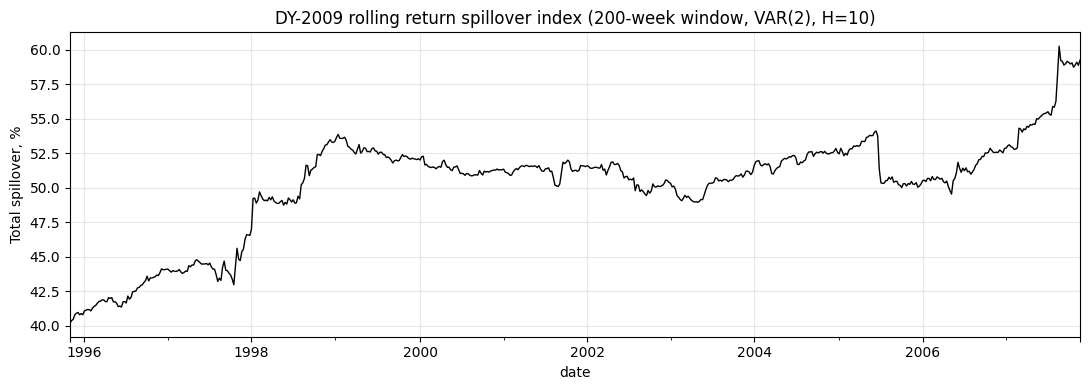

In [7]:
ret_dyn = dynamic_connectedness(returns, window=200, horizon=10, method="orthogonalized", lags=2)

fig, ax = plt.subplots(figsize=(11, 4))
ret_dyn.total.plot(ax=ax, color="black", lw=1)
ax.set_title("DY-2009 rolling return spillover index (200-week window, VAR(2), H=10)")
ax.set_ylabel("Total spillover, %")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()